In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv('penguins.csv')
X = df[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']]
X = X.dropna()
print("Dữ liệu đã sẵn sàng:")
print(X.head())

Dữ liệu đã sẵn sàng:
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0              39.1             18.7              181.0       3750.0
1              39.5             17.4              186.0       3800.0
2              40.3             18.0              195.0       3250.0
4              36.7             19.3              193.0       3450.0
5              39.3             20.6              190.0       3650.0


In [12]:
km_inertias, km_scores = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(X, km.labels_))
    
    print(f"Processing K-Means with k = {k}, Inertia = {km.inertia_:.2f}, Silhouette Score = {silhouette_score(X, km.labels_):.4f}")

Processing K-Means with k = 2, Inertia = 81821416.59, Silhouette Score = 0.6218
Processing K-Means with k = 3, Inertia = 58460376.78, Silhouette Score = 0.6291
Processing K-Means with k = 4, Inertia = 29758452.55, Silhouette Score = 0.5548
Processing K-Means with k = 5, Inertia = 16333665.35, Silhouette Score = 0.5529
Processing K-Means with k = 6, Inertia = 11231866.87, Silhouette Score = 0.5317
Processing K-Means with k = 7, Inertia = 8720457.13, Silhouette Score = 0.5067
Processing K-Means with k = 8, Inertia = 6450352.13, Silhouette Score = 0.5147
Processing K-Means with k = 9, Inertia = 4795852.70, Silhouette Score = 0.5265
Processing K-Means with k = 10, Inertia = 3681675.16, Silhouette Score = 0.5307


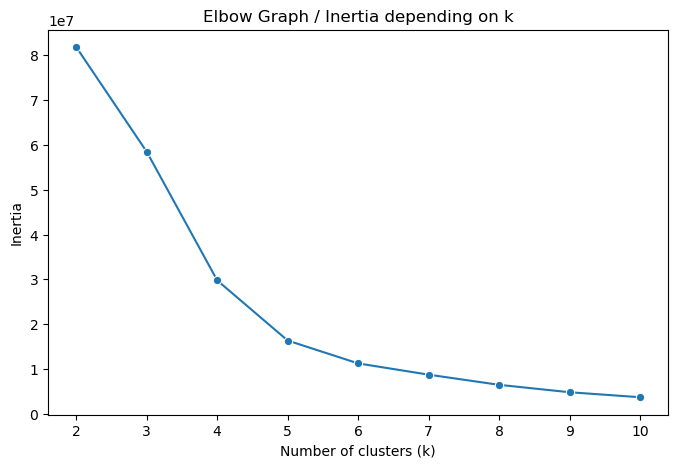

In [13]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(2, 11), y=km_inertias, marker='o')
plt.title('Elbow Graph / Inertia depending on k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

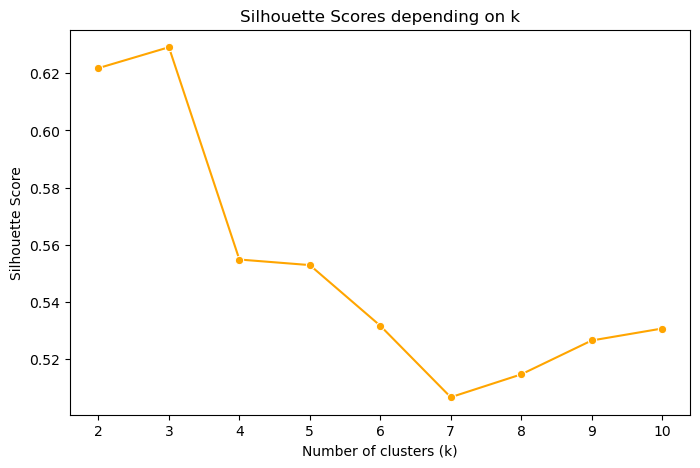

In [14]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(2, 11), y=km_scores, marker='o', color='orange')
plt.title('Silhouette Scores depending on k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [16]:
km_final = KMeans(n_clusters=3, random_state=42).fit(X)
X['Label'] = km_final.labels_
for k in range(3):
    print(f'Cluster nb : {k}')
    print(X[X.Label == k].describe())
    print('\n' + '='*50 + '\n')

Cluster nb : 0
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
count        208.000000       208.000000         208.000000   208.000000   
mean          41.846635        18.064423         192.096154  3652.163462   
std            5.383899         1.431658           7.967348   373.731519   
min           32.100000        13.500000         172.000000  2700.000000   
25%           37.700000        17.200000         187.000000  3400.000000   
50%           40.600000        18.100000         191.000000  3662.500000   
75%           45.800000        18.900000         196.250000  3950.000000   
max           58.000000        21.500000         216.000000  4350.000000   

       Label  
count  208.0  
mean     0.0  
std      0.0  
min      0.0  
25%      0.0  
50%      0.0  
75%      0.0  
max      0.0  


Cluster nb : 1
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
count        133.000000       133.000000         133.000000   133.000000